In [1]:
import sys
import os
sys.path.append(os.curdir)
import run_fit2

In [31]:
directory = "/Users/penny/Box/ffp_fish_overguide/"
outdir = "/Users/penny/FM_MCMC/output/"
out_file = os.path.join(directory, 'ffp_fish_overguide_0_52.out')
obsgroups = ["F146", "F087", "F213"]
match = 0 #ref observatory


fit = run_fit2.fitcomp()
fit.set_mcmc_params(n_steps=10000,n_burn=2000,thin=5)
fit.run_case(directory, out_file,outdir,obsgroups,match,2)
#fit.run_case(directory, out_file, outdir, obsgroup, match):


/Users/penny/FM_MCMC/SL_FFP/data_utils.py:123: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  fsm = pd.read_csv(path, delim_whitespace=True,header=None,comment=None,engine='python',nrows=4,index_col=False)


FM sigmas: [0.00022181210735334404, 0.007192685403164301, 0.14105988526463162, 0.10217366084955358, 6.0712530905537764e-05, 0.050509541442980296]
{'t0': 28.28728468157, 'log_tE': -1.2337754851808826, 'u0': 0.1955351666293, 'log_rho': -0.25633005506666656, 'F0': 1.0, 'log_fs': -0.7381482134808466}


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [19:39<00:00,  8.48it/s]

Processing Event 2 complete.


In [32]:
fit.run_output()

/Users/penny/FM_MCMC/output/ffp_fish_overguide_0_52_2.pdf
here


AttributeError: 'fitcomp' object has no attribute 'sig_cov_fm'

In [44]:
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib as mpl

def A(F, fs):
    return (F - (1 - fs)) / fs

def mag(F, ms, fs):
    m0 = ms + 2.5 * np.log10(fs)
    return m0 - 2.5 * np.log10(F)

def magerr(F, e, ms, fs):
    return (2.5 / np.log(10)) * e / F

def plot_corner_with_ellipses(samples: np.ndarray, parameters_to_fit: list, cov_mcmc: np.ndarray, 
                              cov_fm: np.ndarray, params_gulls: list, sigma_fm: np.ndarray, 
                              sigma_mcmc: np.ndarray, finite_source: bool, output_pdf: PdfPages,
                              lc_name: str,
                              title: str = "FFP Microlensing Parameter Uncertainties: FM Estimates vs MCMC Posterior"):
    
    n = len(parameters_to_fit)
    # Choose labels only for the keys you actually have
    base_map = {
        "t0":   r"$t_0$",
        "log_t0": r"$\log t_0$",
        "tE":   r"$t_E$",
        "log_tE": r"$\log t_E$",
        "u0":   r"$u_0$",
        "log_u0": r"$\log u_0$",
        "rho":  r"$\rho$",
        "log_rho": r"$\log \rho$",
        "F0" : r"$F_0$",
        "fs":   r"$f_s$",
        "log_fs": r"$\log f_s$"
    }

    labels = [base_map[p] for p in parameters_to_fit]
    mpl.rcParams['xtick.labelsize'] = 18
    mpl.rcParams['ytick.labelsize'] = 18
    mpl.rcParams['axes.formatter.use_mathtext'] = True
    mpl.rcParams['axes.formatter.limits'] = [-2, 2]
    mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman','Palatino','Georgia'],
    'font.size': 16,
    'axes.titlesize': 30,
    'axes.labelsize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#666666',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,})

    # Set up figure with constrained layout
    fig = plt.figure(figsize=(3*n + 4, 3*n), constrained_layout=False)
    gs = fig.add_gridspec(n, n + 1, width_ratios=[1]*n + [0.70],wspace=0.02, hspace=0.02)

    # Corner on left nxn subgrid
    corner_axs = np.array([
        [fig.add_subplot(gs[i, j]) for j in range(n)]
        for i in range(n)
    ])
    corner.corner(
        samples,
        labels=labels,
        figsize=(1.5 * n, 1.5 * n),
        show_titles=True,
        title_fmt=".3f",
        fig=fig,
        axes=corner_axs,
        label_kwargs={"fontsize":20, "labelpad":2},
        title_kwargs={"fontsize":20, "pad":2},
        quantiles=[0.158, 0.5, 0.842],
        levels=[0.158, 0.842],   # just 1σ filled
        plot_contours=False,
        fill_contours=True,
        contour_kwargs={"colors":["tab:blue","tab:red"], "alpha":0.7, "linewidths":[1.5,1.5]},
        hist_kwargs={"density":False, "color":"gray", "alpha":0.9},
        plot_datapoints=True,
        space=0.03,
        use_math_text=True
    )

    # Overplot Fisher vs MCMC ellipses
    med = np.median(samples, axis=0)
    θ = np.linspace(0, 2*np.pi, 200)
    for i in range(1, n):
        for j in range(i):
            ax = corner_axs[i,j]
            # Fisher (red dashed)
            Cf = cov_fm[np.ix_([j,i],[j,i])]
            if np.any(Cf):
                vals, vecs = np.linalg.eigh(Cf)
                order = np.argsort(vals)[::-1]
                vals, vecs = vals[order], vecs[:,order]
                ang = np.arctan2(vecs[1,0], vecs[0,0])
                a,b = np.sqrt(2.28*vals)
                R = np.array([[np.cos(ang), -np.sin(ang)],[np.sin(ang),  np.cos(ang)]])
                ell = np.column_stack([a*np.cos(θ), b*np.sin(θ)]).dot(R.T)
                ax.plot(ell[:,0]+med[j], ell[:,1]+med[i],
                        c="tab:red", ls="--", lw=2)
            # MCMC (blue solid)
            Cc = cov_mcmc[np.ix_([j,i],[j,i])]
            vals, vecs = np.linalg.eigh(Cc)
            order = np.argsort(vals)[::-1]
            vals, vecs = vals[order], vecs[:,order]
            ang = np.arctan2(vecs[1,0], vecs[0,0])
            a,b = np.sqrt(2.28*vals)
            R = np.array([[np.cos(ang), -np.sin(ang)],[np.sin(ang),  np.cos(ang)]])
            ell = np.column_stack([a*np.cos(θ), b*np.sin(θ)]).dot(R.T)
            ax.plot(ell[:,0]+med[j], ell[:,1]+med[i],
                    c="tab:blue", ls="-", lw=2)

    fig.legend(
        handles=[
            Line2D([0],[0], c="tab:blue", lw=2, label="MCMC"),
            Line2D([0],[0], c="tab:red",  lw=2, ls="--", label="Fisher")
        ],
        loc="upper right",
        ncol=2,
        frameon=False,
        fontsize=20,
        bbox_to_anchor=(0.95, 0.63)
    )


    tab_ax = fig.add_subplot(gs[:, -1])
    tab_ax.axis("off")
    tab_ax.set_position([0.7, 0.10, 0.15, 0.78]) 
    table_data = [
        [base_map[p],
         f"{params_gulls[idx]:.3g}",
         f"{sigma_fm[idx]:.3g}",
         f"{sigma_mcmc[idx]:.3g}"]
        for idx, p in enumerate(parameters_to_fit)
    ]
    cols = ["Parameter", "Value", r"$\sigma_{\rm FM}$", r"$\sigma_{\rm MCMC}$"]
    tbl = tab_ax.table(
        cellText=table_data,
        colLabels=cols,
        cellLoc="center",
        loc="center",
        colWidths=[0.35, 0.35, 0.35, 0.35],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(20)
    tbl.scale(1.5, 2.5)



    #fig.suptitle(title, fontsize=30, x=0.63,y=0.95)
    #output_pdf.savefig(fig)
    
    
    output_filename = f'{outdir}{os.path.basename(lc_name)[:-3]}.fmmcmc.png'
    print(f"Saving {output_filename}")
    plt.savefig(output_filename)
    plt.show()
    plt.close(fig)



def plot_lc(t0,tE,data_df,
            fsm,
            match: int = 0,
            nobs: int = 3,
            displayobs: list = None,
            labels: list = None,
            obsgroup: list = None,
            models: list = None,
            output_pdf: PdfPages = None,
            lc_name: str = None):

    from cycler import cycler
    plt.rc('axes', prop_cycle=cycler('color', ['y','c','m']))
    fig, ax = plt.subplots(figsize=(15,6))
    fs0 = float(fsm.iloc[0, match+1])
    ms0 = float(fsm.iloc[-1, match+1])
    m0 = ms0 + 2.5*np.log10(fs0)
    lc_data = data_df.iloc[8:].to_numpy(dtype=float)
    if displayobs is None:
        displayobs = list(range(nobs))
    for ii, obs in enumerate(displayobs):
        d = lc_data[lc_data[:,5] == obs]
        fs = float(fsm.iloc[0, obs+1])
        mu = A(d[:,1], fs)
        mi = mag(fs0*mu + 1 - fs0, ms0, fs0)
        sigmi = magerr(fs0*mu + 1 - fs0, d[:,2], ms0, fs0)
        ax.errorbar(d[:,0], mi, yerr=sigmi, fmt='o', ms=8, label=obsgroup[ii])
    if models is not None:
        for model_t in models:
            ax.plot(lc_data[lc_data[:,5]==match,0], model_t, alpha=0.7)
    d_match = lc_data[lc_data[:,5] == match]
    fs = float(fsm.iloc[0, match+1])
    mu_true = A(d_match[:,3], fs)
    mu_fit  = A(d_match[:,7], fs)
    mitrue  = mag(fs0*mu_true + 1 - fs0, ms0, fs0)
    mifit   = mag(fs0*mu_fit  + 1 - fs0, ms0, fs0)
    ax.plot(d_match[:,0], mitrue, '-', color='k', alpha=0.5, zorder=10)
    #ax.plot(d_match[:,0], mifit, '--', color='r', zorder=11)
    ax.set(xlabel='Time (days)', ylabel='Magnitude')
    ax.set(xlim=(t0-1,t0+1))
    ax.tick_params(labelsize=20)
    ax.invert_yaxis()
    ax.legend(fontsize=20)
    if output_pdf is not None:
        output_pdf.savefig(fig)
        plt.close(fig)
    else:
        if lc_name is not None:
            output_filename = f'{outdir}{os.path.basename(lc_name)[:-3]}.fmmcmclc.png'
            print(f"Saving {output_filename}")
            plt.savefig(output_filename)
        plt.show()


def plot_parameter_evolution(sampler, parameters_to_fit: list, output_pdf: PdfPages):
    """
    Plot the MCMC walker evolution for each parameter.
    """
    chain = sampler.get_chain()     # shape = (n_walkers, n_steps, n_dim)
    n_dim = chain.shape[-1]
    fig, axes = plt.subplots(n_dim, 1, figsize=(8,2*n_dim), sharex=True)
    for i in range(n_dim):
        axes[i].plot(chain[:,:,i], alpha=0.3)
        axes[i].set_ylabel(parameters_to_fit[i])
        axes[i].yaxis.set_label_coords(-0.1, 0.5)
    axes[-1].set_xlabel("step number")
    output_pdf.savefig(fig)
    plt.close(fig)

Saving /Users/penny/FM_MCMC/output/ffp_fish_overguide_0_52_2.det.fmmcmc.png


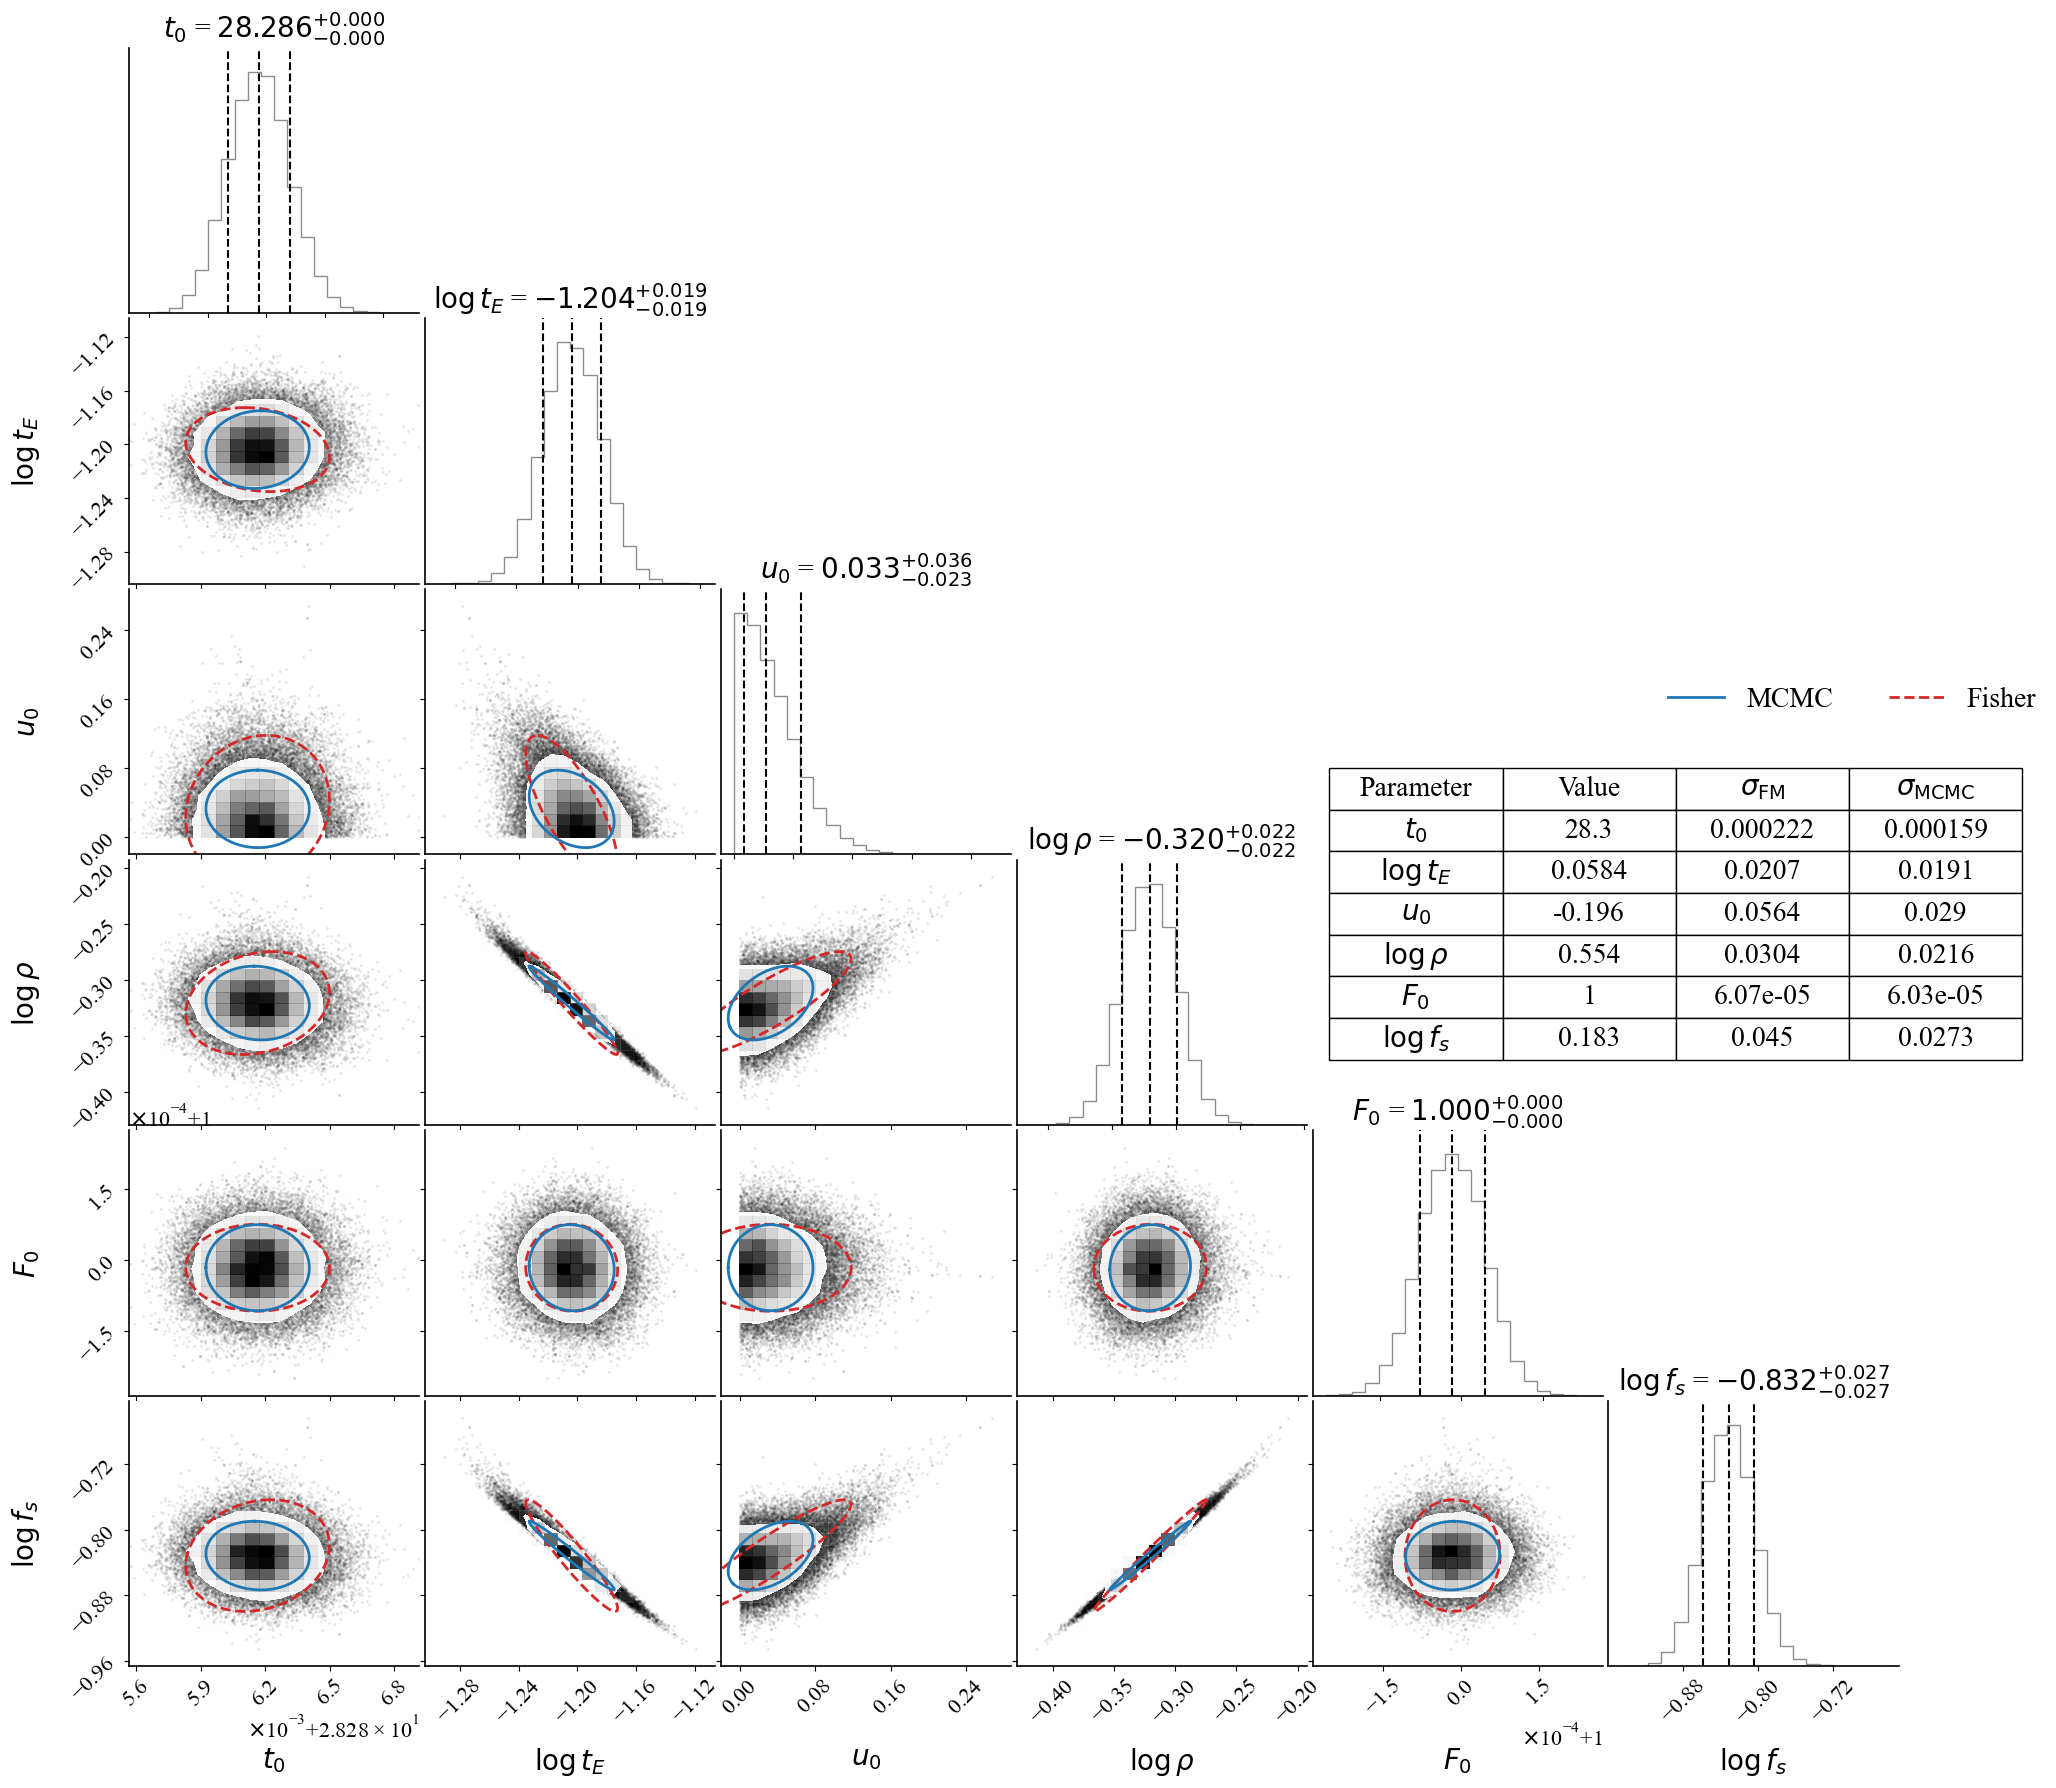

In [45]:
plot_corner_with_ellipses(fit.samples, fit.parameters_to_fit, fit.cov_mcmc,
                                      fit.cov_fm, fit.params_gulls, fit.sigmas_fm,
                                      fit.sigma_mcmc, fit.finite_source,None,fit.lc_file)

In [35]:
fit.samples.shape

(48000, 6)

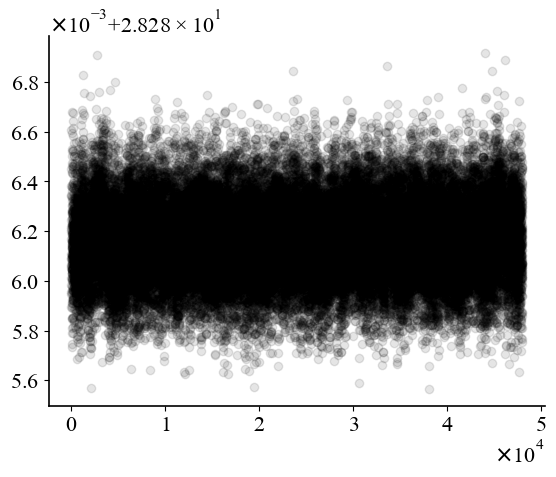

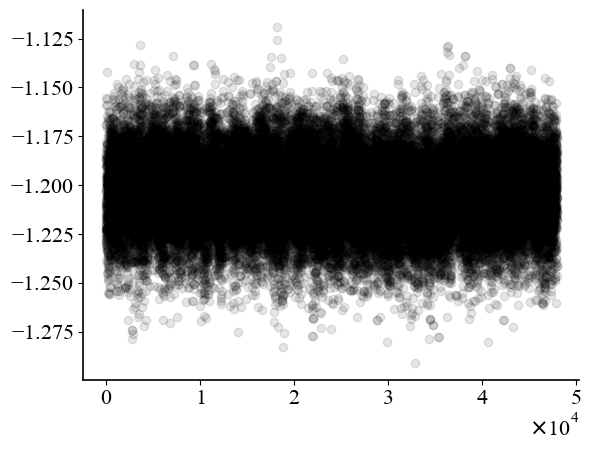

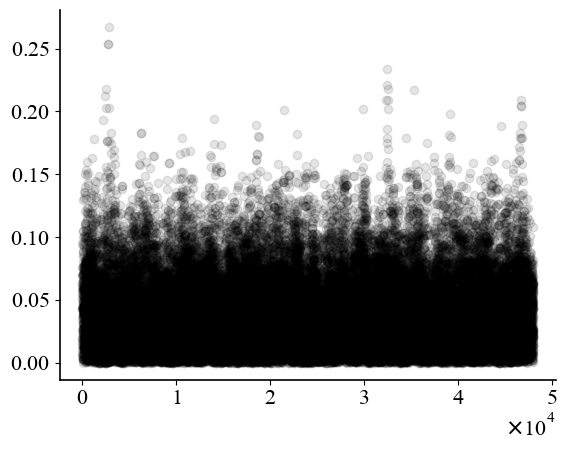

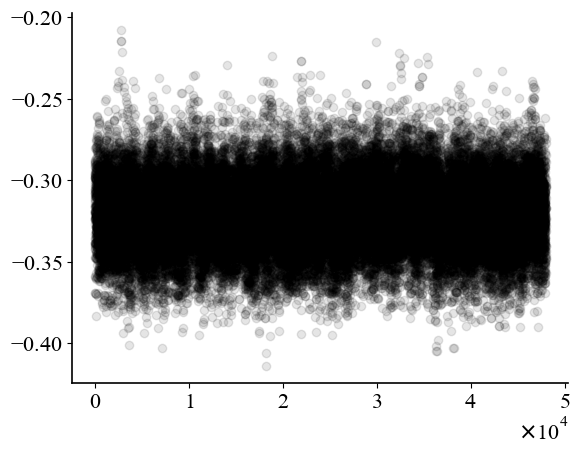

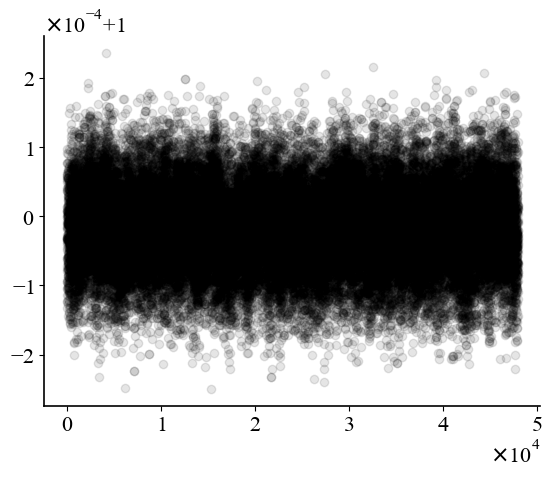

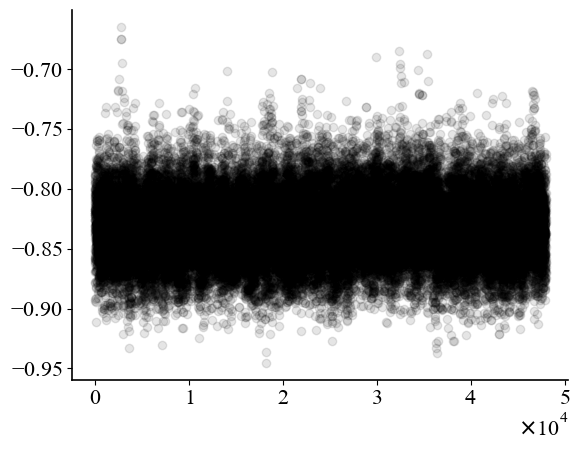

In [36]:
for i in range(6):
    plt.figure()
    plt.plot(fit.samples[:,i],'ko',alpha=0.1)
    plt.show()

In [37]:
for i in range(6):
    print(f"{fit.parameters_to_fit[i]} - {np.std(fit.samples[:,i]):.4f} {fit.sigmas_fm[i]:.4f} {0.5*(np.percentile(fit.samples[:,i],84)-np.percentile(fit.samples[:,i],16)):.4f}")

t0 - 0.0002 0.0002 0.0002
log_tE - 0.0192 0.0207 0.0190
u0 - 0.0297 0.0564 0.0289
log_rho - 0.0218 0.0304 0.0215
F0 - 0.0001 0.0001 0.0001
log_fs - 0.0277 0.0450 0.0271


In [ ]:
import pandas as pd
def sig_fm(path):
    with open(path) as f:
        lines = f.read().splitlines()
    df0 = pd.DataFrame({'name': lines})
    df  = df0['name'].str.split(expand=True)

    fm_rows = df.iloc[54:].astype(float).to_numpy()
    
    print(fm_rows)

    sigma_t0   = fm_rows[1, 0]
    sigma_tE   = fm_rows[1, 1]
    sigma_u0   = fm_rows[1, 2]
    sigma_rho  = fm_rows[1, 3]
    sigma_F0   = fm_rows[1, 4]
    sigma_fs   = fm_rows[1, 5]

    sigmas_fm = [sigma_t0, sigma_tE, sigma_u0, sigma_rho, sigma_F0, sigma_fs]
    print("FM sigmas:", sigmas_fm)
    return sigmas_fm

In [ ]:
directory = "/Users/penny/Box/ffp_fish_overguide/"
outdir = "/Users/penny/FM_MCMC/output/"
out_file = os.path.join(directory, 'ffp_fish_overguide_0_52.out')

sig_fm(directory + "ffp_fish_overguide_0_52_2.det.fm.0")

Saving /Users/penny/FM_MCMC/output/ffp_fish_overguide_0_52_2.det.fmmcmclc.png


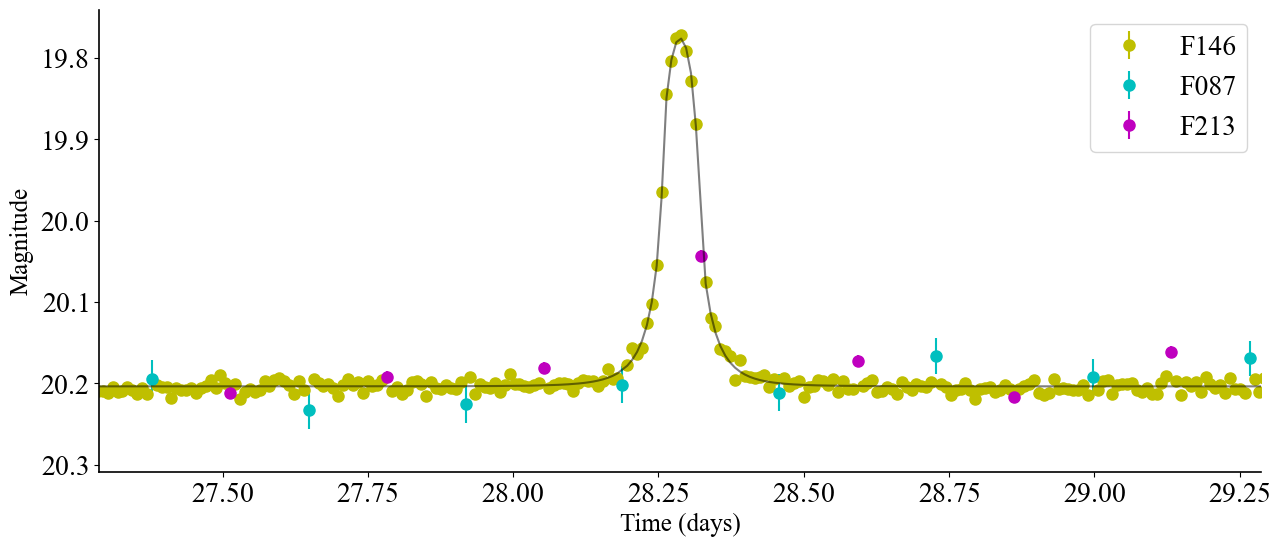

In [46]:
plot_lc(fit.t0, fit.tE, fit.data_df, fit.fsm, match=fit.match, nobs=len(fit.obsgroup), displayobs=None, obsgroup=fit.obsgroup, models=None, output_pdf=None,lc_name = fit.lc_file)